In [21]:
from pathlib import Path

GTFS_PATH = Path("data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )


In [29]:
import zipfile
import pandas as pd

with zipfile.ZipFile(GTFS_PATH, "r") as z:
    names = z.namelist()
    print("Number of files in zip:", len(names))
    for n in names[:24]:
            print(" -", n)


Number of files in zip: 24
 - GTFS_Copenhagen/
 - __MACOSX/._GTFS_Copenhagen
 - GTFS_Copenhagen/transfers.txt
 - __MACOSX/GTFS_Copenhagen/._transfers.txt
 - GTFS_Copenhagen/agency.txt
 - __MACOSX/GTFS_Copenhagen/._agency.txt
 - GTFS_Copenhagen/calendar_dates.txt
 - __MACOSX/GTFS_Copenhagen/._calendar_dates.txt
 - GTFS_Copenhagen/stop_times.txt
 - __MACOSX/GTFS_Copenhagen/._stop_times.txt
 - GTFS_Copenhagen/frequencies.txt
 - __MACOSX/GTFS_Copenhagen/._frequencies.txt
 - GTFS_Copenhagen/shapes.txt
 - __MACOSX/GTFS_Copenhagen/._shapes.txt
 - GTFS_Copenhagen/trips.txt
 - __MACOSX/GTFS_Copenhagen/._trips.txt
 - GTFS_Copenhagen/attributions.txt
 - __MACOSX/GTFS_Copenhagen/._attributions.txt
 - GTFS_Copenhagen/stops.txt
 - __MACOSX/GTFS_Copenhagen/._stops.txt
 - GTFS_Copenhagen/calendar.txt
 - __MACOSX/GTFS_Copenhagen/._calendar.txt
 - GTFS_Copenhagen/routes.txt
 - __MACOSX/GTFS_Copenhagen/._routes.txt


In [48]:
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_54205/753648010.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


Text(0.5, 1.0, 'Copenhagen Routes + Stops (Filtered)')

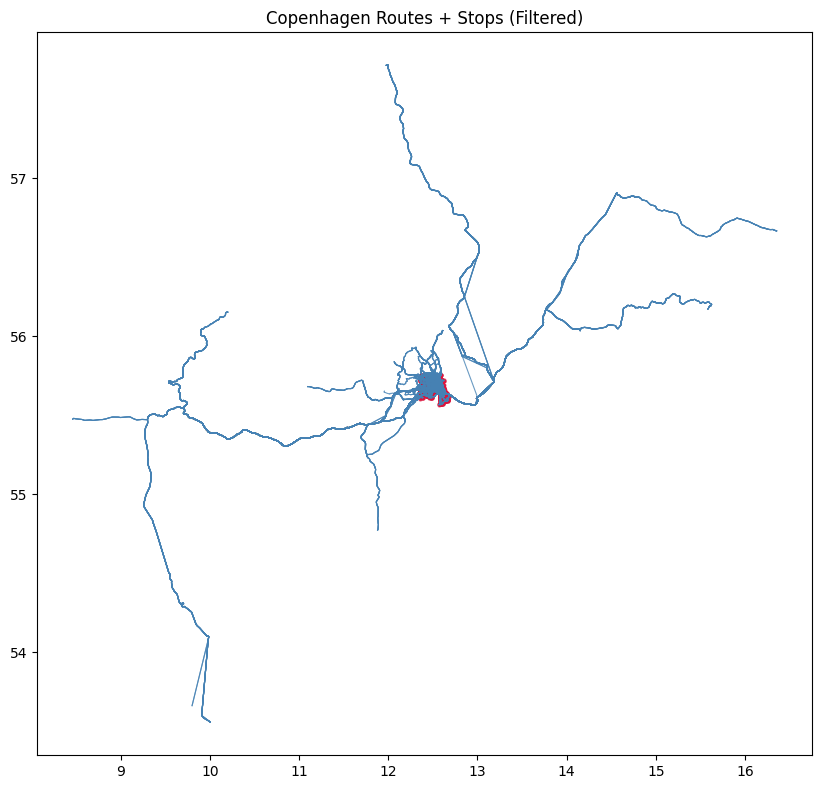

In [49]:
import geopandas as gpd
from shapely.geometry import Point, LineString

# Copenhagen bounding box (approx). Adjust if needed.
COPENHAGEN_BBOX = {
    "min_lon": 12.35,
    "max_lon": 12.75,
    "min_lat": 55.55,
    "max_lat": 55.75,
}

# Filter stops by bbox
stops_cph = stops[
    (stops.stop_lon.between(COPENHAGEN_BBOX["min_lon"], COPENHAGEN_BBOX["max_lon"])) &
    (stops.stop_lat.between(COPENHAGEN_BBOX["min_lat"], COPENHAGEN_BBOX["max_lat"]))
].copy()

# Filter stop_times -> trips -> routes based on filtered stops
stop_times_cph = stop_times[stop_times.stop_id.isin(stops_cph.stop_id)].copy()
trips_cph = trips[trips.trip_id.isin(stop_times_cph.trip_id)].copy()
routes_cph = routes[routes.route_id.isin(trips_cph.route_id)].copy()

# Filter shapes to only those used by the filtered trips
shapes_cph = shapes[shapes.shape_id.isin(trips_cph.shape_id.dropna())].copy()

# Stops -> GeoDataFrame
stops_gdf = gpd.GeoDataFrame(
    stops_cph,
    geometry=[Point(xy) for xy in zip(stops_cph.stop_lon, stops_cph.stop_lat)],
    crs="EPSG:4326",
)

# Shapes -> LineString per shape_id
shapes_sorted = shapes_cph.sort_values(["shape_id", "shape_pt_sequence"])
lines = []
for shape_id, grp in shapes_sorted.groupby("shape_id"):
    coords = list(zip(grp.shape_pt_lon, grp.shape_pt_lat))
    if len(coords) > 1:
        lines.append({"shape_id": shape_id, "geometry": LineString(coords)})

shapes_gdf = gpd.GeoDataFrame(lines, crs="EPSG:4326")

# Plot routes + stops
ax = shapes_gdf.plot(figsize=(10, 10), linewidth=0.8, color="steelblue", alpha=0.8)
stops_gdf.plot(ax=ax, markersize=4, color="crimson", alpha=0.6)
ax.set_title("Copenhagen Routes + Stops (Filtered)")


<Axes: >

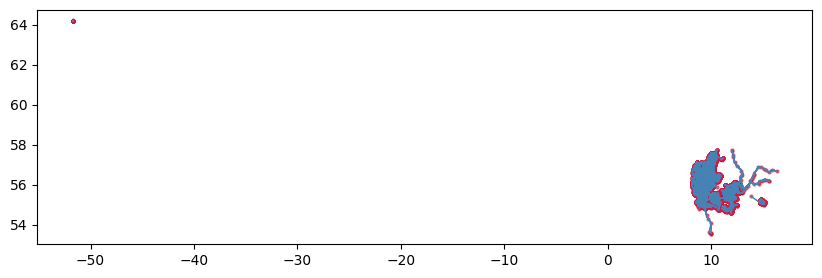

In [50]:
import geopandas as gpd
from shapely.geometry import Point, LineString

# Stops -> GeoDataFrame
stops_gdf = gpd.GeoDataFrame(
    stops,
    geometry=[Point(xy) for xy in zip(stops.stop_lon, stops.stop_lat)],
    crs="EPSG:4326",
)

# Shapes -> LineString per shape_id
shapes = shapes.sort_values(["shape_id", "shape_pt_sequence"])
lines = []
for shape_id, grp in shapes.groupby("shape_id"):
    coords = list(zip(grp.shape_pt_lon, grp.shape_pt_lat))
    if len(coords) > 1:
        lines.append({"shape_id": shape_id, "geometry": LineString(coords)})

shapes_gdf = gpd.GeoDataFrame(lines, crs="EPSG:4326")

ax = shapes_gdf.plot(figsize=(10, 10), linewidth=0.8, color="steelblue")
stops_gdf.plot(ax=ax, markersize=4, color="crimson", alpha=0.6)
